In [7]:
import ast
import pandas as pd
df = pd.read_csv(r'C:\Users\GEORGE TECHNOLOGY EN\Documents\data_jobs.csv')

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

In [8]:

df['job_skills']= df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)


In [9]:
df[['job_title_short','job_skills']].head()

,job_title_short,job_skills
0,Senior Data Engineer,NaN
1,Data Analyst,"[r, python, sql, nosql, power bi, tableau]"
2,Data Engineer,"[python, sql, c#, azure, airflow, dax, docker,..."
3,Data Engineer,"[python, c++, java, matlab, aws, tensorflow, k..."
4,Data Engineer,"[bash, python, oracle, aws, ansible, puppet, j..."


In [11]:
df_exploded = df.explode('job_skills')

<Axes: xlabel='job_skills'>

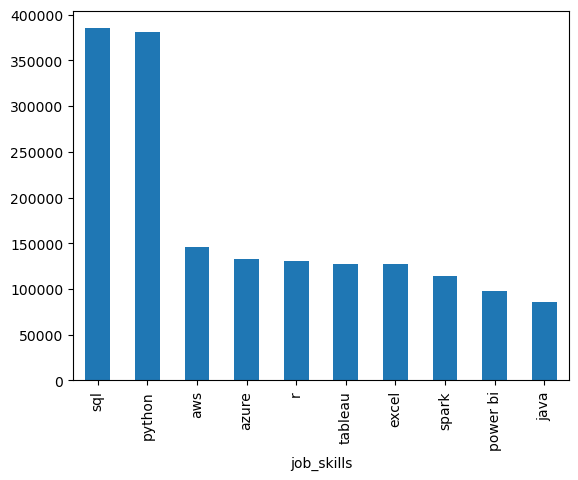

In [13]:
df_exploded['job_skills'].value_counts().head(10).plot(kind = 'bar')

In [14]:
df_exploded = df.explode('job_skills')

In [16]:
skill_count = df_exploded.groupby(['job_title_short','job_skills']).size()

In [22]:
df_skill_count = skill_count.reset_index(name='skill_count')

In [24]:
df_skill_count = df_skill_count.sort_values(by='skill_count', ascending= False)

In [25]:
df_skill_count

,job_title_short,job_skills,skill_count
1066,Data Scientist,python,113711
865,Data Engineer,sql,113130
830,Data Engineer,python,108022
625,Data Analyst,sql,92428
1101,Data Scientist,sql,78982
...,...,...,...
1270,Machine Learning Engineer,nuix,1
1254,Machine Learning Engineer,mlr,1
1255,Machine Learning Engineer,monday.com,1
697,Data Engineer,chainer,1


In [36]:
job_title = 'Data Analyst'
top_skill = 10

df_skill_final = df_skill_count[df_skill_count['job_title_short']== job_title].head(top_skill).copy()

In [39]:
from matplotlib import pyplot as plt

<function matplotlib.pyplot.show(close=None, block=None)>

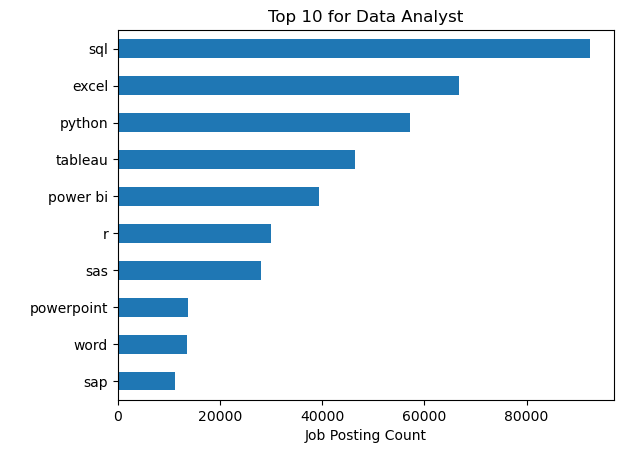

In [46]:
df_skill_final.plot(kind = 'barh', x='job_skills', y='skill_count')
plt.gca().invert_yaxis()
plt.title(f'Top {top_skill} for {job_title}')
plt.xlabel('Job Posting Count')
plt.ylabel(' ')
plt.legend().set_visible(False)
plt.show

In [38]:
df_skill_final

,job_title_short,job_skills,skill_count
625,Data Analyst,sql,92428
494,Data Analyst,excel,66860
590,Data Analyst,python,57190
638,Data Analyst,tableau,46455
583,Data Analyst,power bi,39380
594,Data Analyst,r,29996
606,Data Analyst,sas,27998
585,Data Analyst,powerpoint,13822
664,Data Analyst,word,13562
605,Data Analyst,sap,11280
